In [1]:
# import argparse

# def str_to_bool(value):
#     """Convert argument string to boolean."""
#     if isinstance(value, bool):
#         return value
#     if value.lower() in ('true', '1', 'yes', 'y'):
#         return True
#     elif value.lower() in ('false', '0', 'no', 'n'):
#         return False
#     else:
#         raise argparse.ArgumentTypeError("Boolean value expected (true/false or 1/0).")
        
# def int_or_str(val):
#     try:
#         return int(val)
#     except ValueError:
#         return val

# parser = argparse.ArgumentParser()
# parser.add_argument("--index", type=int_or_str, required=True, help="Filename index")
# parser.add_argument("--subset_size", type=float, required=True)
# parser.add_argument("--noadv", type=str_to_bool, required=True)

# parser.add_argument("--max_epochs", type=int, required=True)

# parser.add_argument("--KL_scaling", type=float, required=True)
# parser.add_argument("--n_cat_discriminator_train", type=int, required=True)
# parser.add_argument("--n_pert_discriminator_train", type = int, required = True)
# parser.add_argument("--n_adversarial_start", type = int, required = True)

# parser.add_argument("--cat_dropout", type=float, required=True)

# parser.add_argument("--generator_dropout_rate", type=float, required=True)
# parser.add_argument("--n_layers_vae", type=int, required=True)

# parser.add_argument("--gen_max_lr", type=float, required=True)
# parser.add_argument("--cat_max_lr", type=float, required=True)
# parser.add_argument("--pert_max_lr", type=float, required=True)


# parser.add_argument("--cat_max_penalty_weight", type=int, required=True)

# ########################################################################
# args = parser.parse_args()
# fn = str(args.index)

# subset_size = args.subset_size
# no_adv = args.noadv
# KL_scaling = args.KL_scaling
# max_epochs = args.max_epochs
# n_cat_discriminator_train = args.n_cat_discriminator_train
# n_pert_discriminator_train = args.n_pert_discriminator_train
# n_adversarial_start = args.n_adversarial_start
# # pert_spectral_norm = args.pert_spectral_norm
# # cat_spectral_norm = args.cat_spectral_norm

# gen_max_lr = args.gen_max_lr
# cat_max_lr = args.cat_max_lr
# pert_max_lr = args.pert_max_lr

# cat_dropout = args.cat_dropout

# generator_dropout_rate = args.generator_dropout_rate
# n_layers_vae = args.n_layers_vae


# cat_max_penalty_weight = args.cat_max_penalty_weight


# # python test_run.py --index 49 --subset_size 0.05 --noadv false --max_epochs 600 --KL_scaling 5e-5 --n_cat_discriminator_train 5 --n_pert_discriminator_train 5 --cat_dropout 0.3 --n_adversarial_start 0 --gen_max_lr 1e-4 --cat_max_lr 1e-2 --pert_max_lr 1e-2 --cat_max_penalty_weight 11 --generator_dropout_rate 0.7 --n_layers_vae 1 


In [2]:
fn = '1v2'
subset_size = 0.05
no_adv = False
max_epochs = 3 #600 #5

KL_scaling = 1e-2

n_cat_discriminator_train = 5
n_pert_discriminator_train = 5
cat_dropout = 0.1
n_adversarial_start = 601 #601

gen_max_lr = 1e-4
cat_max_lr = 1e-3
pert_max_lr = 1e-2


# pert_spectral_norm = True
# cat_spectral_norm = True

generator_dropout_rate = 0.7 
n_layers_vae  = 1

cat_max_penalty_weight = 11

In [3]:
import os
import time
import math

import pandas as pd
import numpy as np
import scanpy as sc

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn

import sys
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS import preprocess as pp 
from scLEMBAS.model.train import TrainSC
from scLEMBAS.model.scl import SignalingModel

import Tahoe_utils as Tu

/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/nobackup/


[KeOps] Warning : There were warnings or errors :
<stdin>:1:10: fatal error: cuda.h: No such file or directory
compilation terminated.

[KeOps] Warning : 
    The location of Cuda header files cuda.h and nvrtc.h could not be detected on your system.
    You must determine their location and then define the environment variable CUDA_PATH,
    either before launching Python or using os.environ before importing keops. For example
    if these files are in /vol/cuda/10.2.89-cudnn7.6.4.38/include you can do :
      import os
      os.environ['CUDA_PATH'] = '/vol/cuda/10.2.89-cudnn7.6.4.38'
    
[KeOps] Compiling cuda jit compiler engine ... 
[KeOps] Warning : There were warnings or errors :
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/keopscore/binders/nvrtc/nvrtc_jit.cpp:16:10: fatal error: cuda.h: No such file or directory
 #include <cuda.h>
          ^~~~~~~~
compilation terminated.

OK
[pyKeOps] Compiling nvrtc binder for python ... 
[KeOps] W

In [4]:
subset = True

In [5]:
n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

seed = 888
mod_seed = 888
data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'
author = 'Tahoe100M'

device = "cuda" if torch.cuda.is_available() else "cpu"



Load data:

In [6]:
sn_ppis = pd.read_csv(os.path.join(data_path, 'processed', author + '_sn_ppis.csv'), 
                     index_col = 0)
source_label = 'source_genesymbol'
target_label = 'target_genesymbol'
weight_label = 'mode_of_action'
stimulation_label = 'consensus_stimulation'
inhibition_label = 'consensus_inhibition'

tf_adata = io.read_tfad(os.path.join(data_path, 'processed', author + '_consensus_tf_activity.h5ad'))
adata = sc.read_h5ad(os.path.join(data_path, 'processed', author + '_expr_in.h5ad'))
expr = adata.to_df().copy()

# basic formatting checks
if not np.all(tf_adata.var_names == sorted(tf_adata.var_names)):
    raise ValueError('Ensure TF adata features are sorted on input')
    
if not np.all(adata.obs_names == tf_adata.obs_names):
    raise ValueError('Ensure gene expression and TF activity sample features are orderd the same')
    
if len(set(tf_adata.obs.drug)) != len(tf_adata.obs.drug.cat.categories):
    raise ValueError('Make sure only present perturbations are in the categorical columns')
    
if len(set(tf_adata.obs.cell_line)) != len(tf_adata.obs.cell_line.cat.categories):
    raise ValueError('Make sure only present cell lines are in the categorical columns')

/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Train/test split:

In [7]:
train_split, test_split = Tu.Tahoe100M_split(tf_adata,
                                          train_frac = 0.9, 
                                          min_drug_frac = 0.7, 
                                          min_cell_line_frac = 0.7, 
                                          exclude_control = True, 
                                          max_attempts = 1000, 
                                          seed = seed)

train_cells = train_split['barcodes']
test_cells = test_split['barcodes']

cell_line_counts = pd.DataFrame({
    'train': train_split['cell_line_counts'],
    'test': test_split['cell_line_counts']
}).sort_values(by = 'train', ascending = True)

drug_counts = pd.DataFrame({
    'train': train_split['drug_counts'],
    'test': test_split['drug_counts']
}).sort_values(by = 'train', ascending = True)



In [8]:
cell_line_counts

,train,test
cell_line,,
CVCL_0371,23,6
CVCL_0546,24,5
CVCL_1056,24,5
CVCL_0480,26,3
CVCL_1550,26,3
CVCL_0459,27,2
CVCL_1285,27,2
CVCL_0023,28,1
CVCL_0399,28,1


In [9]:
drug_counts

,train,test
drug,,
Neratinib (maleate),8,2
Almonertinib (mesylate),8,2
Tofacitinib (citrate),8,2
Rucaparib (phosphate),8,2
Retinoic acid,8,2
Rapamycin,8,2
Norepinephrine (hydrochloride),8,2
Filgotinib,8,2
Tofacitinib,9,1


In [44]:
import collections
import itertools
tracker = collections.defaultdict(set)
for cond in test_conds:
    cl, drug = cond.split('^')
    tracker[cl].add(drug)
    
cell_lines = {cond.split('^')[0] for cond in test_conds}

In [51]:
for cl1, cl2 in (itertools.combinations(cell_lines, 2)):
    if len(tracker[cl1].intersection(tracker[cl2])) > 1:
        print((cl1, cl2))
        print(tracker[cl1].intersection(tracker[cl2]))

('CVCL_0546', 'CVCL_1550')
{'Filgotinib', 'Almonertinib (mesylate)'}


In [50]:
test_conds['CVCL_0546']

['CVCL_0023^Rapamycin',
 'CVCL_0371^Bexarotene',
 'CVCL_0371^Clonidine (hydrochloride)',
 'CVCL_0371^Gefitinib',
 'CVCL_0371^Neratinib (maleate)',
 'CVCL_0371^Rucaparib (phosphate)',
 'CVCL_0371^Tucidinostat',
 'CVCL_0399^Regorafenib',
 'CVCL_0459^Crizotinib (hydrochloride)',
 'CVCL_0459^Norepinephrine (hydrochloride)',
 'CVCL_0480^Piroxicam',
 'CVCL_0480^Rapamycin',
 'CVCL_0480^Retinoic acid',
 'CVCL_0546^Almonertinib (mesylate)',
 'CVCL_0546^Binimetinib',
 'CVCL_0546^Filgotinib',
 'CVCL_0546^Naproxen',
 'CVCL_0546^Vilanterol',
 'CVCL_1056^Cabozantinib (S-malate)',
 'CVCL_1056^Dabrafenib',
 'CVCL_1056^Rucaparib (phosphate)',
 'CVCL_1056^Tofacitinib',
 'CVCL_1056^Tofacitinib (citrate)',
 'CVCL_1119^Norepinephrine (hydrochloride)',
 'CVCL_1285^Neratinib (maleate)',
 'CVCL_1285^Retinoic acid',
 'CVCL_1550^Almonertinib (mesylate)',
 'CVCL_1550^Filgotinib',
 'CVCL_1550^Tofacitinib (citrate)']

In [38]:
cls = {[cond.split('^') for cond in test_conds]}

TypeError: unhashable type: 'list'

In [32]:
test_conds

['CVCL_0023^Rapamycin',
 'CVCL_0371^Bexarotene',
 'CVCL_0371^Clonidine (hydrochloride)',
 'CVCL_0371^Gefitinib',
 'CVCL_0371^Neratinib (maleate)',
 'CVCL_0371^Rucaparib (phosphate)',
 'CVCL_0371^Tucidinostat',
 'CVCL_0399^Regorafenib',
 'CVCL_0459^Crizotinib (hydrochloride)',
 'CVCL_0459^Norepinephrine (hydrochloride)',
 'CVCL_0480^Piroxicam',
 'CVCL_0480^Rapamycin',
 'CVCL_0480^Retinoic acid',
 'CVCL_0546^Almonertinib (mesylate)',
 'CVCL_0546^Binimetinib',
 'CVCL_0546^Filgotinib',
 'CVCL_0546^Naproxen',
 'CVCL_0546^Vilanterol',
 'CVCL_1056^Cabozantinib (S-malate)',
 'CVCL_1056^Dabrafenib',
 'CVCL_1056^Rucaparib (phosphate)',
 'CVCL_1056^Tofacitinib',
 'CVCL_1056^Tofacitinib (citrate)',
 'CVCL_1119^Norepinephrine (hydrochloride)',
 'CVCL_1285^Neratinib (maleate)',
 'CVCL_1285^Retinoic acid',
 'CVCL_1550^Almonertinib (mesylate)',
 'CVCL_1550^Filgotinib',
 'CVCL_1550^Tofacitinib (citrate)']

In [10]:
if subset:
    train_cells = []
    np.random.seed(seed)
    for cond in train_split['conditions'].condition:
        subset_cond = tf_adata.obs[tf_adata.obs.condition == cond]
        subset_cells = list(np.random.choice(
            subset_cond.index,
            size = int(np.round(subset_cond.shape[0] * subset_size)),
            replace = False
        ))
        train_cells+=subset_cells
    tf_adata = tf_adata[tf_adata.obs_names.isin(train_cells + test_cells),:].copy()
    adata = adata[tf_adata.obs_names, :].copy()
    expr = adata.to_df().copy()

**Note: As mentioned in Notebook 00A, when splitting the data into train-test splits, conditions will remain balanced, but drug/cell lines will not be completely balanced (due to OOD, cannot ensure the drug and cell line split is the same as the condition split).** 

# Hyper-parameters:

In [11]:
def generate_lr_params(n_epochs, 
                       max_lr, 
                       lr_scaling_factor=10, 
                       lr_decay=0.75,
                       n_restarts=4,
#                        n_cat_discriminator_train=5,
#                        n_pert_discriminator_train=5,
                       n_adversarial_start=0,
                       role='scl'):
    """
    Generate LR scheduler params for WarmupCosineAnnealingWarmRestarts
    that ensures discriminator and generator follow the same curve in real (epoch) time.

    For 'generator', it updates when either discriminator is active.

    Returns:
        Dict of scheduler parameters
    """

    total_active_epochs = n_epochs
    n_steps = n_epochs  # default for SCL

    if role in ['generator', 'cat_discriminator', 'pert_discriminator']:
        if n_adversarial_start >= n_epochs: # won't be used anyways
            n_adversarial_start = 0
        total_active_epochs = n_epochs - n_adversarial_start
        n_steps = total_active_epochs // 1

#    DEPRECATED: this was necessary when generator trained every n_discriminator_train epochs
#                rather than discriminator training n_discriminator_train times every epoch
#     elif role in 'generator':
#         # Generator steps on any epoch divisible by either cat or pert discriminator schedule
#         effective_epochs = range(n_adversarial_start, n_epochs)
#         n_steps = sum(
#             (e % n_cat_discriminator_train == 0) or (e % n_pert_discriminator_train == 0)
#             for e in effective_epochs
#         )

    T_0 = max(1, n_steps // n_restarts)
    warmup_epochs = max(1, n_steps // 10)

    if warmup_epochs >= T_0:
        warmup_epochs = 0

    return {
        'max_epochs': n_epochs,
        'maximum_learning_rate': max_lr,
        'minimum_learning_rate': max_lr / lr_scaling_factor,
        'lr_restart_epoch': T_0,
        'n_optimizer_resets': 0,
        'lr_decay': lr_decay,
        'lr_restart_factor': 1,
        'warmup_epochs': warmup_epochs
    }


In [12]:
projection_amplitude_in = 10
projection_amplitude_out = 1

bionet_params = {'target_steps': 100, 
                 'max_steps': 120, 
                 'exp_factor': 50, 
                 'tolerance': 1e-5, 
                 'leak': 1e-2}

spectral_radius_params = {'n_probes_spectral': 5, 
                          'power_steps_spectral': 5, 
                          'subset_n_spectral': 5}
target_spectral_radius = 0.9

noise_params = {
    'network_noise_scale': 0.01, 
    'min_network_noise': 0.0015, #0.0025, 
    'gradient_noise_scale': 1e-9, 
    'include_gradient_noise_vae': True, 
    'include_gradient_noise_embedding': True, 
    'constant_gradient_noise': True
    
}


In [13]:
loss_scaler = 100
prediction_loss_fn = torch.nn.MSELoss(reduction='mean')
per_condition_loss = False # TODO: check this


batch_params = {
    'train_batch_size': int(512*8), 
    'test_batch_size': int(512*8), 
    'validation_batch_size': np.nan
}


max_batch_scaler = 24

if subset:
    if subset_size < 0.02:
        batch_scaler = 2
    else:
        batch_scaler = int(8 * round(math.ceil(subset_size / 0.05) * 0.05, 2) / 0.05)
        batch_scaler = min(batch_scaler, max_batch_scaler)

    batch_params['train_batch_size'] = int(512*batch_scaler)
    batch_params['test_batch_size'] = int(512*batch_scaler)
# max_epochs = 600


max_lr = 0.001
lr_scaling_factor = 10
lr_decay = 0.75
n_restarts = 4
lr_params = generate_lr_params(n_epochs = max_epochs, 
                               max_lr = max_lr, 
                               lr_scaling_factor = lr_scaling_factor, 
                               lr_decay = lr_decay,
                               n_restarts = n_restarts,
                               n_adversarial_start = np.nan, 
#                                n_cat_discriminator_train = np.nan, 
#                                n_pert_discriminator_train = np.nan,
                               role = 'scl')

# reset_state = False # DEPRECATED
# initialize_fc = True # DEPRECATED

In [14]:
bionet_params['cat_max_norm'] = 100
regularization_params = {
    'input_lambda_L2': 0, # irrelevant because setting the requires grad to False
    
    'bn_weights_lambda_L2': 1e-7,
    'moa_lambda_L1': 1e2,
    'uniform_lambda_L2': 1e-7, 
    'uniform_min': -1/projection_amplitude_out,
    'uniform_max': 1/projection_amplitude_out,
    'adj_scaling_KL': 0,  # using uniform/bn_weights already
    'adj_prior_mu': 0, # irrelevant because adj_scaling_KL is 0
    'adj_prior_sigma': 0.2, # irrelevant because adj_scaling_KL is 0
    
    'output_weights_lambda_L2': 1e-7,
    'output_bias_lambda_L2': 1e-7,
    
    'spectral_loss_factor': 1e-6,
    
    
    'global_bias_lambda_L2': 0, # using KL divergence instead
    'global_bias_lambda_L1': 0, # using KL divergence instead
    'cat_bias_lambda_L2': 0, # using cat max norm
    'cat_bias_lambda_L1': 0, # using cat max norm
    'cat_bias_orthogonality_scaler': 0
}

In [15]:
training_params = {
    **lr_params, 
    **batch_params, 
    **regularization_params, 
    **spectral_radius_params,
    **noise_params
}

training_params['prediction_loss_fn_scaler'] = loss_scaler

VAE:

In [16]:
# building
# n_layers_vae = 1
n_nodes = len(set(sn_ppis[source_label].tolist() + sn_ppis[target_label].tolist()))
vae_n_hidden_nodes = list(np.round(np.linspace(adata.shape[1], n_nodes, n_layers_vae + 2)).astype(int)[1:-1])

# generator_dropout_rate = 0.7
vae_mod_params = {
    'vae_batch_momentum': 0.01, 
    'vae_layer_norm': False, 
    'vae_dropout_rate': generator_dropout_rate,
    'vae_activation_fn': nn.LeakyReLU,
    'vae_n_hidden_nodes': vae_n_hidden_nodes, 
    'vae_var_min': 1e-4

} 
bionet_params = {**bionet_params, **vae_mod_params}

# training
vae_params = {
    'prior_mu': 0, 
    'prior_sigma': 1,
    'scaling_KL': KL_scaling, #1e-2, 
    'lambda_l2': 1e-5, 
    'optimizer': torch.optim.Adam
}

 
n_restarts_adversarial = 4
vae_lr_params = generate_lr_params(n_epochs = max_epochs,
                                   max_lr = gen_max_lr, #max_lr,
                                   lr_scaling_factor = lr_scaling_factor, 
                                   lr_decay = lr_decay,
                                   n_restarts = n_restarts_adversarial,
                                   n_adversarial_start = n_adversarial_start,
#                                n_cat_discriminator_train = n_cat_discriminator_train, 
#                                n_pert_discriminator_train = n_pert_discriminator_train,
                                   role = 'generator')
vae_params = {**vae_params, **vae_lr_params}
del vae_params['max_epochs']


Discriminator:

In [17]:
discriminator_lambda_L2 = 1e-3

discriminator_params = {
    'batch_momentum': None,
    'layer_norm': False,
    'spectral_norm': np.nan, #False,
    'dropout_rate': np.nan,
    'activation_fn': nn.LeakyReLU,
    'n_hidden_nodes': np.nan,
    'lr_restart_factor': 1,
    'optimizer': torch.optim.Adam,
    'discriminator_lambda_L2': discriminator_lambda_L2,
    'discriminator_penalty_weight': np.nan, 
    'bionet_activation': False,
    'smooth_labels': True, 
    'epsilon_smooth': np.nan
}

In [18]:
# architecture -- pert >> cat bc harder classification problem
cat_n_layers_disc = 3
cat_disc_n_hidden_nodes = list(np.round(np.linspace(n_nodes, 
                                                    cell_line_counts.shape[0],
                                                    cat_n_layers_disc + 2)).astype(int)[1:-1])
cat_discriminator_params = discriminator_params.copy()
cat_discriminator_params['n_hidden_nodes'] = cat_disc_n_hidden_nodes
cat_discriminator_params['dropout_rate'] = cat_dropout

cat_spectral_norm = True
cat_discriminator_params['spectral_norm'] = cat_spectral_norm
if cat_spectral_norm:
    cat_discriminator_params['discriminator_lambda_L2'] = 0


pert_n_layers_disc = 4
pert_disc_n_hidden_nodes = list(np.round(np.linspace(n_nodes, 
                                                     drug_counts.shape[0], 
                                                     pert_n_layers_disc + 2)).astype(int)[1:-1])

# add 3 additional "starting" layers since classifying perturbation is difficult
pert_disc_n_hidden_nodes = [pert_disc_n_hidden_nodes[0]]*3 + pert_disc_n_hidden_nodes

pert_discriminator_params = discriminator_params.copy()
pert_discriminator_params['n_hidden_nodes'] = pert_disc_n_hidden_nodes
pert_discriminator_params['dropout_rate'] = 0.1

pert_spectral_norm = True
pert_discriminator_params['spectral_norm'] = pert_spectral_norm
if pert_spectral_norm:
    pert_discriminator_params['discriminator_lambda_L2'] = 0

cat_discriminator_params['epsilon_smooth'] = 1/tf_adata.obs.cell_line.nunique()
pert_discriminator_params['epsilon_smooth'] = 1/tf_adata.obs.drug.nunique()

In [19]:
# adverserial penalty curve
# cat_max_penalty_weight = 11
cat_b_adv = 2.5
pert_max_penalty_weight = 10 #15
pert_b_adv = 2 #10

if n_adversarial_start < max_epochs:
    cat_discriminator_params['discriminator_penalty_weight'] = pp.discriminator_weight_curve(
        n_epochs = max_epochs - n_adversarial_start,
        min_penalty_weight = 0.1,
        max_penalty_weight = cat_max_penalty_weight,
        a = 1,
        b = cat_b_adv, 
        curve_type = 'power')

    n_pert_train = int(max_epochs/2)
    pert_discriminator_penalty_weight = [0] * n_pert_train
    pert_discriminator_penalty_weight += pp.discriminator_weight_curve(
        n_epochs = max_epochs - n_pert_train - n_adversarial_start,
        min_penalty_weight = 1e-5,
        max_penalty_weight = pert_max_penalty_weight,
        a = 1,
        b = pert_b_adv, 
        curve_type = 'power')
    pert_discriminator_params['discriminator_penalty_weight'] = pert_discriminator_penalty_weight
else:
    cat_discriminator_params['discriminator_penalty_weight'] = [0]*max_epochs
    pert_discriminator_params['discriminator_penalty_weight'] = [0]*max_epochs




# # DEPRECATED: when n_discriminator_train trained generator less frequently instead of disc more frequently
# def expand_elements(lst, n_discriminator_train):
#     return [x for x in lst for _ in range(n_discriminator_train)]
# n_adj = 1 if n_cat_discriminator_train > 1 else 0
# cat_discriminator_penalty_weight = pp.discriminator_weight_curve(
#     n_epochs = int((max_epochs - n_adversarial_start)/n_cat_discriminator_train) - n_adj,
#     min_penalty_weight = 0.1,
#     max_penalty_weight = cat_max_penalty_weight,
#     a = 1,
#     b = cat_b_adv, 
#     curve_type = 'power')
# cat_discriminator_penalty_weight = expand_elements(cat_discriminator_penalty_weight, n_cat_discriminator_train)
# cat_discriminator_penalty_weight = [0]*n_adj*n_cat_discriminator_train + cat_discriminator_penalty_weight
# cat_discriminator_params['discriminator_penalty_weight'] = cat_discriminator_penalty_weight

# n_pert_train = 300
# pert_discriminator_penalty_weight = [0] * n_pert_train

# n_adj = n_pert_discriminator_train if n_pert_discriminator_train > 1 and n_pert_train == 0 else 0
# pdpw2 = pp.discriminator_weight_curve(
#     n_epochs = int((max_epochs - n_pert_train - n_adversarial_start)/n_pert_discriminator_train) - n_adj,
#     min_penalty_weight = 1e-5,
#     max_penalty_weight = pert_max_penalty_weight,
#     a = 1,
#     b = pert_b_adv, 
#     curve_type = 'power')
# pdpw2 = expand_elements(pdpw2, n_pert_discriminator_train)
# pert_discriminator_penalty_weight += [0]*n_adj*n_pert_discriminator_train + pdpw2


# pert_discriminator_params['discriminator_penalty_weight'] = pert_discriminator_penalty_weight

In [20]:
# discriminator LRs

# categorical
discriminator_lr_params = generate_lr_params(
    n_epochs = max_epochs,
    max_lr = cat_max_lr,
    lr_scaling_factor = lr_scaling_factor, 
    lr_decay = lr_decay,
    n_restarts = n_restarts_adversarial,
    n_adversarial_start = n_adversarial_start, 
#     n_pert_discriminator_train = np.nan,
#     n_cat_discriminator_train = n_cat_discriminator_train,
    role = 'cat_discriminator')
del discriminator_lr_params['max_epochs']

cat_discriminator_params = {**cat_discriminator_params, **discriminator_lr_params}

# perturbation
discriminator_lr_params = generate_lr_params(
    n_epochs = max_epochs,
    max_lr = pert_max_lr,
    lr_scaling_factor = lr_scaling_factor, 
    lr_decay = lr_decay,
    n_restarts = n_restarts_adversarial,
    n_adversarial_start = n_adversarial_start, 
#     n_pert_discriminator_train = n_pert_discriminator_train,
#     n_cat_discriminator_train = np.nan,
    role = 'pert_discriminator')
del discriminator_lr_params['max_epochs']

pert_discriminator_params = {**pert_discriminator_params, **discriminator_lr_params}

Visualize hyperparameters:

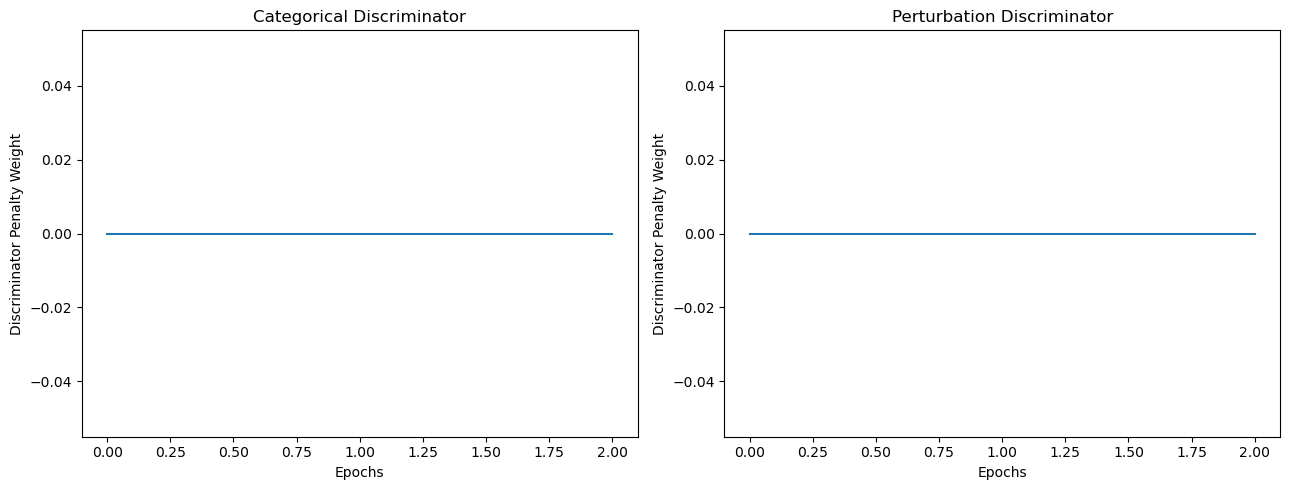

In [21]:
fig, ax = plt.subplots(ncols = 2, figsize = (13,5))
sns.lineplot(cat_discriminator_params['discriminator_penalty_weight'], ax = ax[0])
ax[0].set_title('Categorical Discriminator')

sns.lineplot(pert_discriminator_params['discriminator_penalty_weight'], ax = ax[1])
ax[1].set_title('Perturbation Discriminator')

for i in range(2):
    ax[i].set_xlabel('Epochs')
    ax[i].set_ylabel('Discriminator Penalty Weight')
    
fig.tight_layout();

# Build model and trainer

In [22]:
# input stimulation
X_in = pd.get_dummies(tf_adata.obs.drug).astype(int)
X_in.drop(columns = 'DMSO_TF', inplace = True) # all 0s

In [23]:
# lr_mod = SignalingModel(
#     net = sn_ppis,
#     X_in = X_in,
#     y_out = tf_adata.to_df().copy(), 
#     expr = expr, 
#     covariates = tf_adata.obs.copy(),
#     categorical_covariate_keys = ['cell_line'],
#     projection_amplitude_in = projection_amplitude_in, 
#     projection_amplitude_out = projection_amplitude_out,
#     weight_label = weight_label, source_label = source_label, target_label = target_label,
#     bionet_params = bionet_params, 
#     dtype = torch.float32, device = device, seed = mod_seed)

# lr_mod.input_layer.weights.requires_grad = False # don't learn scaling factors for the ligand input concentrations
# lr_mod.signaling_network.prescale_weights(target_radius = target_spectral_radius) # spectral radius



# lr_trainer = TrainSC(
#     mod = lr_mod,
#     prediction_optimizer = torch.optim.Adam,
#     prediction_loss_fn = prediction_loss_fn, 
#     per_condition_loss = per_condition_loss,
#     n_adversarial_start = n_adversarial_start, 
#     n_cat_discriminator_train = n_cat_discriminator_train,
#     n_pert_discriminator_train = n_pert_discriminator_train,
#     gradient_ascent = True,
#     cat_discriminator_params = cat_discriminator_params,
#     pert_discriminator_params = pert_discriminator_params,
#     vae_params = vae_params,
#     hyper_params = training_params,
#     train_split = {'train': train_cells, 'test': test_cells, 'validation': None}, 
#     train_seed = mod_seed, 
#     track_test = True,
#     track_validation = False, 
#     n_eval_cells = np.nan, 
#     n_eval_bootstrap = np.nan
# )

# import collections
# from tqdm import trange
# lrs = collections.defaultdict(list)
# for e in trange(lr_trainer.hyper_params['max_epochs']):
#     lr_trainer._run_adv = (lr_trainer.n_adversarial_start <= e)
    
#     lrs['scl'].append(lr_trainer.prediction_optimizer.param_groups[0]['lr'])
#     lrs['vae'].append(lr_trainer.vae_learning['optimizer'].param_groups[0]['lr'])
#     lrs['cat_discriminator'].append(lr_trainer.cat_discriminator['optimizer'].param_groups[0]['lr'])
#     lrs['pert_discriminator'].append(lr_trainer.pert_discriminator['optimizer'].param_groups[0]['lr'])


#     lr_trainer.lr_scheduler.step()
#     if lr_trainer._run_adv:
#         lr_trainer.cat_discriminator['lr_scheduler'].step()
#         lr_trainer.pert_discriminator['lr_scheduler'].step()
#         lr_trainer.vae_learning['lr_scheduler'].step()
        
# lrs = pd.DataFrame(lrs)

# ncols = lrs.shape[1]
# fig, ax = plt.subplots(ncols = ncols, figsize = (5.1*ncols, 5))

# for (j, col) in enumerate(lrs.columns):
#     sns.lineplot(lrs[col], ax = ax[j])
#     ax[j].set_title(col)
    
# fig.tight_layout()
# ;
# del lr_trainer

In [24]:
mod = SignalingModel(
    net = sn_ppis,
    X_in = X_in,
    y_out = tf_adata.to_df().copy(), 
    expr = expr, 
    covariates = tf_adata.obs.copy(),
    categorical_covariate_keys = ['cell_line'],
    projection_amplitude_in = projection_amplitude_in, 
    projection_amplitude_out = projection_amplitude_out,
    weight_label = weight_label, source_label = source_label, target_label = target_label,
    bionet_params = bionet_params, 
    dtype = torch.float32, device = device, seed = mod_seed)

mod.input_layer.weights.requires_grad = False # don't learn scaling factors for the ligand input concentrations
mod.signaling_network.prescale_weights(target_radius = target_spectral_radius) # spectral radius


In [25]:
trainer = TrainSC(
    mod = mod,
    prediction_optimizer = torch.optim.Adam,
    prediction_loss_fn = prediction_loss_fn, 
    per_condition_loss = per_condition_loss,
    n_adversarial_start = n_adversarial_start, 
n_cat_discriminator_train = n_cat_discriminator_train,
n_pert_discriminator_train = n_pert_discriminator_train,
    gradient_ascent = True,
    cat_discriminator_params = cat_discriminator_params,
    pert_discriminator_params = pert_discriminator_params,
    vae_params = vae_params,
    hyper_params = training_params,
    train_split = {'train': train_cells, 'test': test_cells, 'validation': None}, 
    train_seed = mod_seed, 
    track_test = True,
    track_validation = False, 
    n_eval_cells = np.nan, 
    n_eval_bootstrap = np.nan
)

In [26]:
mod = trainer.train_model(verbose = True)

 33%|███████████████                              | 1/3 [00:08<00:17,  8.88s/it]

i=0, l(tr)=89.36949, l(te)=nan, s=0.23954, r=0.00010, v=0.00000


100%|█████████████████████████████████████████████| 3/3 [00:26<00:00,  8.80s/it]

Training ran in: 0 min 26.42 sec


In [27]:
n_adversarial_start = trainer.n_adversarial_start
n_cat_discriminator_train = trainer.n_cat_discriminator_train
n_pert_discriminator_train = trainer.n_pert_discriminator_train

train_stats_df = trainer.stats['train'].copy()

keep_mask = pd.Series([
    (e >= n_adversarial_start) 
    for e in (train_stats_df.epoch - 1)
])
# # keep_cat_mask = (train_stats_df.epoch - 1) % (n_cat_discriminator_train == 0)
# # keep_pert_mak = (train_stats_df.epoch - 1) % (n_pert_discriminator_train == 0)
# # keep_gen_mask = pd.Series([
# #     (e >= n_adversarial_start) and 
# #     ((e % n_cat_discriminator_train == 0) or (e % n_pert_discriminator_train == 0))
# #     for e in (train_stats_df.epoch - 1)
# # ])

# # masks for n_discriminator_train for visualization
# for col in ['global_bias_kl_divergence', 'vae_param_reg_loss', 'vae_grad_l2_norm']:
#     train_stats_df[col] = train_stats_df[col].mask(
#         (~keep_gen_mask),  # this second condition is a sanity check, shouldn't be necessary
#         np.nan
#     )
    
# # since total is a function of adversarial parameters that also go to 0 on n_discriminator train
# for col in ['train_loss_total']:
#     train_stats_df[col] = train_stats_df[col].mask(
#         (~keep_gen_mask), 
#         np.nan
#     )
    
# similarly, sign reg goes to 0 with 0 violations which makes visualization difficult
# we will ignore those for a smoother curve
for col in ['sign_reg_loss']:
    train_stats_df[col] = train_stats_df[col].mask(
        (train_stats_df[col] == 0), 
        np.nan
    )

# delete this
train_stats_df = train_stats_df.groupby('epoch').mean().reset_index() 

    
cat_col = 'cell_line'
pert_col = 'drug'
    
train_cells = trainer.X_train.index.tolist()
test_cells = trainer.X_test.index.tolist()

train_conds = sorted(tf_adata.obs.loc[train_cells, :].condition.unique())
test_conds = sorted(tf_adata.obs.loc[test_cells, :].condition.unique())



<Axes: xlabel='epoch', ylabel='rnn_iter_t'>

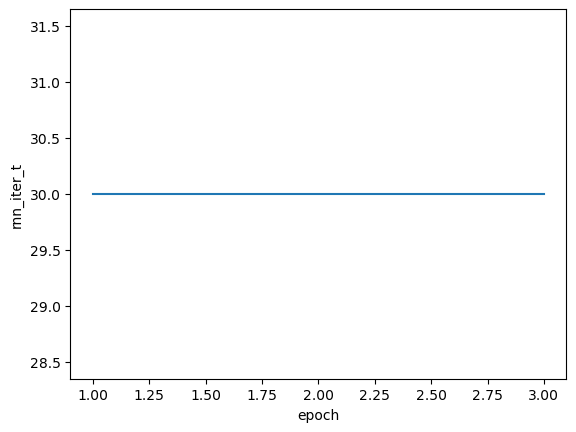

In [159]:
self = trainer
from scLEMBAS.model.train import *

In [160]:
start_time = time.time()
self.mod.signaling_network.implement_mask() # shouldn't be necessary bc called in signaling_network init

torch.autograd.set_detect_anomaly(True)

for e in trange(self.hyper_params['max_epochs']):
    self._run_adv = (self.n_adversarial_start <= e)


    cur_lr = self.prediction_optimizer.param_groups[0]['lr']
    self.cat_discriminator['_cur_lr'] = self.cat_discriminator['optimizer'].param_groups[0]['lr']
    self.pert_discriminator['_cur_lr'] = self.pert_discriminator['optimizer'].param_groups[0]['lr']
    self.vae_learning['_cur_lr'] = self.vae_learning['optimizer'].param_groups[0]['lr']

    cur_catdisc_lambda = self.cat_discriminator['params']['discriminator_penalty_weight'][e] if self._run_adv else self._zero.clone()
    cur_pertdisc_lambda = self.pert_discriminator['params']['discriminator_penalty_weight'][e] if self._run_adv else self._zero.clone()

    # self._run_adv = (
    #     (e >= self.n_adversarial_start)
    #     and (cur_catdisc_lambda != 0 or cur_pertdisc_lambda != 0)
    # )



    # iterate through batches
    if self.mod.seed:
        utils.set_seeds(self.mod.seed + e)
    break
for batch, (X_in_, y_out_, covariates_idx_, expr_) in enumerate(self.train_dataloader):
    break

  0%|                                                   | 0/600 [00:00<?, ?it/s]


In [161]:
self.mod.train()
if not self._run_adv:
    freeze_model(self.mod.signaling_network.vae)
else:
    unfreeze_model(self.mod.signaling_network.vae)

self.prediction_optimizer.zero_grad()
self.cat_discriminator['optimizer'].zero_grad()
self.pert_discriminator['optimizer'].zero_grad()
self.vae_learning['optimizer'].zero_grad()

X_in_, y_out_, covariates_idx_, expr_ = X_in_.to(self.mod.device), y_out_.to(self.mod.device), covariates_idx_.to(self.mod.device), expr_.to(self.mod.device)

######################## Forward Pass ########################
X_full = self.mod.input_layer(X_in_) # transform to full network with ligand input concentrations

# add noise to ninput
utils.set_seeds(self.mod.seed + self.mod._gradient_seed_counter)
network_noise = torch.randn(X_full.shape, device = X_full.device)
noise_scale_factor = self.hyper_params['network_noise_scale'] * (cur_lr/self.lr_scheduler.max_lr)
noise_scale_factor = max(noise_scale_factor, self.hyper_params['min_network_noise'])
X_full = X_full + (noise_scale_factor * network_noise) # randomly add noise to signaling network input, makes model more robust                Y_full, bias_terms = self.mod.signaling_network(X_full = X_full, 

In [162]:
X_full = X_full
covariates_idx = covariates_idx_
expr = expr_
self = self.mod.signaling_network

In [163]:
diff_vals = []
std_per_step = []

In [164]:
bias_cats = torch.zeros_like(X_full.T, device = self.device, dtype = self.dtype)
# add categorical covariates
for cat_group_idx in range(covariates_idx.shape[1]):
    cat_group = self._cat_group_idx[cat_group_idx]
    bias_cats += self.cat_embeddings[cat_group](covariates_idx[:,cat_group_idx]).T
#             # the indexing above would be the equivalent of this:
#             embedding = self.cat_embeddings[cat_group].weight.clone()
#             one_hot = self.one_hot[cat_group][labels_idx].to(embedding.dtype)
#             bias_tot += torch.matmul(one_hot, embedding)

bias_mu, bias_log_sigma_squared, bias_global = self.vae(expr)
bias_global.data.masked_fill_(mask = self.bias_mask.T.expand(bias_global.shape[0], -1), value = 0.0) # apply bias mask

bias_tot = bias_global.T + bias_cats
X_bias = X_full.T + bias_tot # this is the bias and ligand input combined

# single pass 
#         X_new = torch.mm(self.weights, X_bias)
#         X_new = self.activation(X_new, self.bionet_params['leak'])        

# RNN
X_new = torch.zeros_like(X_bias) #initialize hidden state values at 0
for t in range(self.bionet_params['max_steps']): # like an RNN, updating from previous time step
    X_old = X_new
    X_new = torch.mm(self.weights, X_new) # scale matrix by edge weights

    X_new = X_new + X_bias  # add original values and bias       
    X_new = self.activation(X_new, self.bionet_params['leak'])
    std_per_step.append(X_new.std(dim=1).mean().item())

#     if (t % 10 == 0) and (t > 20):
    diff = torch.max(torch.abs(X_new - X_old))    
    diff_vals.append((t, diff))
    if diff.lt(self.bionet_params['tolerance']):
        break

Y_full = X_new.T

In [165]:
t = [i[0] for i in diff_vals]
diffs = [i[1].detach().item() for i in diff_vals]

[0.3713458776473999,
 0.3752315044403076,
 0.37563851475715637,
 0.3757093548774719,
 0.3757226765155792,
 0.375725120306015,
 0.3757255971431732,
 0.375725656747818,
 0.3757256865501404,
 0.3757256865501404,
 0.3757256865501404,
 0.3757256865501404,
 0.3757256865501404,
 0.3757256865501404,
 0.3757256865501404,
 0.3757256865501404,
 0.3757256865501404,
 0.3757256865501404]

''

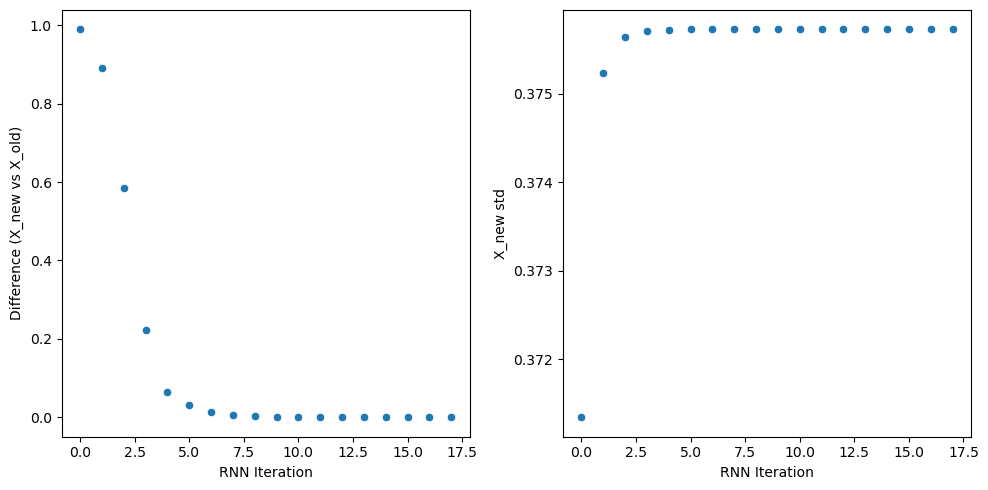

In [170]:
fig, ax = plt.subplots(ncols = 2, figsize = (10, 5))
sns.scatterplot(x = t, y = diffs, ax = ax[0])
ax[0].set_xlabel('RNN Iteration')
ax[0].set_ylabel('Difference (X_new vs X_old)')


sns.scatterplot(x = t, y = std_per_step, ax = ax[1])
ax[1].set_xlabel('RNN Iteration')
ax[1].set_ylabel('X_new std')

fig.tight_layout()
;

In [95]:
diff_vals

[(30, tensor(2.3842e-07, device='cuda:0', grad_fn=<MaxBackward1>))]

In [54]:
t

119

In [ ]:
Y_full, bias_terms = self.mod.signaling_network() # train signaling network weights
bias_global, bias_mu, bias_log_sigma_squared = bias_terms

In [ ]:

# set train mode or not (discriminator done below)


if self._run_adv:
    Y_full, bias_terms = self.mod.signaling_network(X_full = X_full, 
                                                    covariates_idx = covariates_idx_, 
                                                    expr = expr_) # train signaling network weights
    bias_global, bias_mu, bias_log_sigma_squared = bias_terms
else:
    Y_full, _ = self.mod.signaling_network.forward_novar(X_full = X_full, 
                                                    covariates_idx = covariates_idx_, 
                                                    expr = expr_) # train signaling network weights

Y_hat = self.mod.output_layer(Y_full)

######################## Categorical DISCRIMINATOR ########################
if self._run_adv:
    for discriminator in self.cat_discriminator['discriminators'].values():
            unfreeze_model(model = discriminator)
    for nd in range(self.n_cat_discriminator_train):
        self.cat_discriminator['optimizer'].zero_grad()
        # discriminator prediction and loss
        cat_discriminator_loss_accuracy = self._zero.clone()
        for cat_group_idx, (cat, discriminator) in enumerate(self.cat_discriminator['discriminators'].items()):
            bias_global_prediction = discriminator(bias_global.detach()) # predicted logits
            # if don't use retain_graph = True, then use bias_global.detach() here

            target = covariates_idx_[:, cat_group_idx]
            if discriminator.n_labels == 2:
                target = target.to(self.mod.dtype).unsqueeze(1)

            cat_discriminator_loss_accuracy += discriminator.loss_fn(bias_global_prediction, target)   

        # discriminator regularization
        cat_discriminator_reg = self._zero.clone()
        for discriminator in self.cat_discriminator['discriminators'].values():
            cat_discriminator_reg += discriminator.L2_reg(self.cat_discriminator['params']['discriminator_lambda_L2'])
        cat_discriminator_loss = cat_discriminator_loss_accuracy + cat_discriminator_reg

        # discriminator optimization
        # NOTE: discriminator is optimized prior to adverserial training (and loss re-calculated)
        cat_discriminator_loss.backward() # if bias global is not detached, need to set retain_graph = True here
        if nd == self.n_cat_discriminator_train - 1: # tracking only
            cat_grad_l2s = np.array([self.get_global_l2_norm(mod_discriminator) for mod_discriminator in self.cat_discriminator['discriminators'].values()])
        self.cat_discriminator['optimizer'].step()

    # freeze discriminator (to prevent updating discriminator gradients when calling discriminator while 
    # training generator adverserially below)
    for discriminator in self.cat_discriminator['discriminators'].values():
        freeze_model(model = discriminator)

    # NOTE: 
    # a good adverserial check here is to see if the vae (and all self.mod) param gradients are still 0, 
    # as the backward pass for prediction has not yet been called; when using the retain_graph = True
    # and not calling bias_global.detach() above, the gradients from calculating the discriminator loss
    # on bias global were leaking into the generator portion

    ######################## Perturbation DISCRIMINATOR ########################
    # same implementation as categorical discriminator currently
    # discriminator prediction and loss
    unfreeze_model(model = self.pert_discriminator['discriminator'])
    for nd in range(self.n_pert_discriminator_train):
        self.pert_discriminator['optimizer'].zero_grad()
        bias_global_prediction = self.pert_discriminator['discriminator'](bias_global.detach()) # predicted logits

        if self.pert_discriminator['discriminator'].n_labels != 2:
            target = X_in_.argmax(dim=1)
            # differentiate between rows with no perturbation and rows with perturbation at column 1 (index 0)
            no_pert = X_in_.sum(dim=1) == 0  
            target[no_pert] = self.pert_discriminator['discriminator'].n_labels - 1 # -1 for indexing
        else:
            target = X_in_#.long().reshape(-1)


        pert_discriminator_loss_accuracy = self.pert_discriminator['discriminator'].loss_fn(bias_global_prediction, target)   

        # discriminator regularization
        pert_discriminator_reg = self.pert_discriminator['discriminator'].L2_reg(self.pert_discriminator['params']['discriminator_lambda_L2'])
        pert_discriminator_loss = pert_discriminator_loss_accuracy + pert_discriminator_reg

        # discriminator optimization
        pert_discriminator_loss.backward()
        if nd == self.n_pert_discriminator_train - 1: # tracking only
            pert_grad_l2 = self.get_global_l2_norm(self.pert_discriminator['discriminator']) # tracking
        self.pert_discriminator['optimizer'].step()
    freeze_model(model = self.pert_discriminator['discriminator'])
else:
    cat_discriminator_loss  = self._zero.clone()
    cat_discriminator_loss_accuracy = self._zero.clone()
    cat_discriminator_reg = self._zero.clone()
    cat_grad_l2s = np.array([0.0]*len(self.cat_discriminator['discriminators']))

    pert_discriminator_loss = self._zero.clone()
    pert_discriminator_loss_accuracy = self._zero.clone()
    pert_discriminator_reg = self._zero.clone()
    pert_grad_l2 = 0.0


######################## LEMBAS and generator ########################
# reconstruction loss
prediction_loss = self.compute_loss(y_out_, Y_hat, X_in_, covariates_idx_)

# lembas regularization
sign_reg = self.mod.signaling_network.sign_regularization(lambda_L1 = self.hyper_params['moa_lambda_L1']) # incorrect MoA
#             ligand_reg = self.mod.ligand_regularization(lambda_L2 = self.hyper_params['ligand_lambda_L2']) # ligand biases
stability_loss, spectral_radius = self.mod.signaling_network.get_SS_loss(Y_full = Y_full.detach(), spectral_loss_factor = self.hyper_params['spectral_loss_factor'],
                                                                    subset_n = self.hyper_params['subset_n_spectral'], n_probes = self.hyper_params['n_probes_spectral'], 
                                                                    power_steps = self.hyper_params['power_steps_spectral'])
uniform_reg = self.mod.uniform_regularization(lambda_L2 = self.hyper_params['uniform_lambda_L2']*cur_lr, Y_full = Y_full, 
                                        target_min = 0, target_max = self.hyper_params['uniform_max']) # uniform distribution

input_param_reg, sn_param_reg, output_param_reg = self.mod.L2_reg(input_lambda_L2=self.hyper_params['input_lambda_L2'],
                            bn_weights_lambda_L2=self.hyper_params['bn_weights_lambda_L2'], 
                            global_bias_lambda_L2=self.hyper_params['global_bias_lambda_L2'], 
                            bias_global = torch.tensor(0) if not self._run_adv else bias_global,
                            cat_bias_lambda_L2=self.hyper_params['cat_bias_lambda_L2'],
                            output_weights_lambda_L2=self.hyper_params['output_weights_lambda_L2'],
                            output_bias_lambda_L2=self.hyper_params['output_bias_lambda_L2'])
sn_bias_l1_reg = self.mod.signaling_network.L1_reg_bias(bias_global = torch.tensor(0) if not self._run_adv else bias_global, 
                                                        global_bias_lambda_L1 = self.hyper_params['global_bias_lambda_L1'], 
                                                        cat_bias_lambda_L1 = self.hyper_params['cat_bias_lambda_L1'])
#                 from collections import OrderedDict
#                 sn_cat_bias_orthogonality_reg = OrderedDict({'cat_bias_orthogonality_loss': 0})
sn_cat_bias_orthogonality_reg = self.mod.signaling_network.cat_orthogonality_regularization(covariates_idx = covariates_idx_,
                                                                                            X_in = X_in_,
                                                                                            regularization_scaler = self.hyper_params['cat_bias_orthogonality_scaler'])
sn_param_reg = {**sn_param_reg, **sn_bias_l1_reg, **sn_cat_bias_orthogonality_reg}
param_reg = input_param_reg + sum(sn_param_reg.values()) + sum(output_param_reg.values())
vae_reg = torch.tensor(0.0)
if self._run_adv:
    vae_reg = self.mod.signaling_network.vae.L2_reg(lambda_L2=self.vae_learning['params']['lambda_l2']) 
param_reg += vae_reg

# NOTE: KL divergence is scaled to match loss magnitudes; no bias regularization given KL regularization
# can use MMD in the future if KL unstable

# for adj matrix 
if self.hyper_params['adj_scaling_KL'] == 0:
    kl_divergence_adj = self._zero.clone()
else:
    unmasked_weights = self.mod.signaling_network.weights[~self.mod.signaling_network.mask]
    kl_divergence_adj = self.hyper_params['adj_scaling_KL'] *kl_divergence_normal(empirical_values = unmasked_weights, 
                                                mu=self.hyper_params['adj_prior_mu'], 
                                                sigma=self.hyper_params['adj_prior_sigma'], 
                                                eps=1e-8)

kl_divergence_gb = self._zero.clone()
if self._run_adv:
    # for global bias
    kl_divergence_gb = self.mod.signaling_network.vae.KL_divergence(z_mu = bias_mu, 
                                                                z_log_sigma_squared = bias_log_sigma_squared, 
                                                                scaling_factor = self.vae_learning['params']['scaling_KL'], 
                                                                prior_mu = self.vae_learning['params']['prior_mu'], 
                                                                prior_sigma = self.vae_learning['params']['prior_sigma'])
tot_pred_loss = prediction_loss + sign_reg + param_reg + stability_loss + uniform_reg + kl_divergence_gb + kl_divergence_adj

pert_adverserial_loss, cat_adverserial_loss = self._zero.clone(), self._zero.clone()
# adverserial portion -- same as discriminator, but recalculating on trained model
if self._run_adv:
    # categorical adversary
    if cur_catdisc_lambda != 0:
        for cat_group_idx, (covariate_cat, discriminator) in enumerate(self.cat_discriminator['discriminators'].items()):
            bias_global_prediction = discriminator(bias_global) 

            target = covariates_idx_[:, cat_group_idx]
            if discriminator.n_labels == 2:
                target = target.to(self.mod.dtype).unsqueeze(1) if not self.gradient_ascent else 1 - target.to(self.mod.dtype).unsqueeze(1)
            else:
                if self.gradient_ascent:
                    utils.set_seeds(self.mod.seed + e + batch)
                    target = self.flip_labels_proportional(true_labels = target, 
                                                                classes = self.cat_class_probs[covariate_cat]['classes'], 
                                                                probs = self.cat_class_probs[covariate_cat]['probs'], 
                                                                n_labels = discriminator.n_labels)

            cat_adverserial_loss += discriminator.loss_fn(bias_global_prediction, target)  

    # perturbation adversary
    if cur_pertdisc_lambda != 0:
        bias_global_prediction = self.pert_discriminator['discriminator'](bias_global) 
        if self.pert_discriminator['discriminator'].n_labels == 2:
            target = X_in_ if not self.gradient_ascent else 1 - X_in_
        else:
            target = X_in_.argmax(dim=1)
            no_pert = X_in_.sum(dim=1) == 0  
            target[no_pert] = self.pert_discriminator['discriminator'].n_labels - 1

            if self.gradient_ascent:
                utils.set_seeds(self.mod.seed + e + batch)
                target = self.flip_labels_proportional(true_labels = target, 
                                                            classes = self.pert_class_probs['classes'], 
                                                            probs = self.pert_class_probs['probs'], 
                                                            n_labels = self.pert_discriminator['discriminator'].n_labels)
        pert_adverserial_loss = self.pert_discriminator['discriminator'].loss_fn(bias_global_prediction, target) 

if self.gradient_ascent:
    # goal is worse accuracy of discriminator
    # without label flipping trick, we are maximizing the loss of the actual labels
    # conversely, with label flipping, we are minimizing the loss with flipped labels
    pert_adverserial_loss = -pert_adverserial_loss
    cat_adverserial_loss = -cat_adverserial_loss

tot_pred_loss = tot_pred_loss - (cur_catdisc_lambda*cat_adverserial_loss) - (cur_pertdisc_lambda*pert_adverserial_loss)

# model gradient
tot_pred_loss.backward()

# tracking
vae_grad_l2 = 0
if self._run_adv:
    vae_grad_l2 = self.get_global_l2_norm(self.mod.signaling_network.vae) 

self.add_gradient_noise(cur_lr, e, batch)
self.prediction_optimizer.step()
if self._run_adv: # even if penalties are 0, there are still regularizations
    self.vae_learning['optimizer'].step()
self.mod.signaling_network.implement_mask() # moved out of forward pass to ensure after last backpass these are 0

# NOTE: 
# a good adverserial check here is to see if the discriminator parameter gradients have changed since 
# calling cat_discriminator_loss.backward(); they should not have, but i've found calling the discriminator forward pass 
# during the adversarial training and the tot_pred_loss.backward() does update them unless I manually freeze them


# bias global masking can stay in forward pass because it is generated during the forward pass and 
# won't be updated in the back pass

sv = np.array([e + 1, batch, cur_lr, self.cat_discriminator['_cur_lr'], self.pert_discriminator['_cur_lr'], self.vae_learning['_cur_lr'],
            time.time() - start_time, spectral_radius, 
    self.mod.signaling_network.count_sign_mismatch(), 
    tot_pred_loss.detach().item(), prediction_loss.detach().item(), #train_pearson_r, 
    sign_reg.detach().item(), stability_loss.detach().item(), uniform_reg.detach().item(), 
    input_param_reg.detach().item(), kl_divergence_adj.detach().item()])
sv = np.concatenate([sv,
                    np.array([v.detach().item() for v in sn_param_reg.values()]),
                    np.array([v.detach().item() for v in output_param_reg.values()]),
                    np.array([vae_reg.detach().item(), vae_grad_l2, kl_divergence_gb.detach().item(),
                            (cur_catdisc_lambda*cat_adverserial_loss).detach().item(), cat_discriminator_loss.detach().item(), 
                            cat_discriminator_loss_accuracy.detach().item(), cat_discriminator_reg.detach().item()]),
                    cat_grad_l2s,
                    np.array([(cur_pertdisc_lambda*pert_adverserial_loss).detach().item(), pert_discriminator_loss.detach().item(), 
                            pert_discriminator_loss_accuracy.detach().item(), pert_discriminator_reg.detach().item(), pert_grad_l2
                            ])
                    ])


self.stats['train'] = np.vstack((self.stats['train'], sv))

# comparable tracking of train data with test data
if self.track_test or self.track_validation:
    eval_sv = self.evaluate_loss(y_out_, X_in_, covariates_idx_, expr_, e, batch)
    self.stats['train_eval'] = np.vstack((self.stats['train_eval'], eval_sv))

# free up CUDA mem
del sign_reg, stability_loss, uniform_reg, param_reg, prediction_loss
del input_param_reg, sn_param_reg, output_param_reg
del vae_reg, kl_divergence_gb, kl_divergence_adj
del cat_discriminator_loss, cat_discriminator_loss_accuracy, cat_discriminator_reg
del pert_discriminator_loss, pert_discriminator_loss_accuracy, pert_discriminator_reg
del X_in_, y_out_, covariates_idx_, X_full, Y_full, Y_hat
utils.clear_memory()

self.lr_scheduler.step()
if self._run_adv:
self.cat_discriminator['lr_scheduler'].step()
self.pert_discriminator['lr_scheduler'].step()
self.vae_learning['lr_scheduler'].step()

# test/validation
data_types = []
if self.track_test:
data_types.append('test')
if self.track_validation:
data_types.append('validation')
for data_type in data_types:
for batch, (X_in_, y_out_, covariates_idx_, expr_) in enumerate(self.__dict__[data_type + '_dataloader']):
    X_in_, y_out_, covariates_idx_, expr_ = X_in_.to(self.mod.device), y_out_.to(self.mod.device), covariates_idx_.to(self.mod.device), expr_.to(self.mod.device)            
    eval_sv = self.evaluate_loss(y_out_, X_in_, covariates_idx_, expr_, e, batch)
    self.stats[data_type] = np.vstack((self.stats[data_type], eval_sv))


if e % (self.hyper_params['max_epochs']/100) == 0 or e == self.hyper_params['max_epochs']:
# vanishing/exploding gradients
param_names = []
for name, param in self.mod.named_parameters():
    if torch.isnan(param).any() or torch.isinf(param).any():
        param_names.append(name)
if len(param_names) > 0:
    log_error = 'NaN/inf values found in model parameters at epoch {}'.format(e)
    log_error += ' for layers ' + ', '.join(param_names)
    logging.error(log_error)
    raise ValueError(log_error)

# masks implemented correctly
correct_masking = True
for idx, cat_group in enumerate(self.mod.signaling_network.cat_embeddings.keys()):
    mask_coords = torch.nonzero(self.mod.signaling_network.cat_embeddings_mask[cat_group].detach())
    embedding_vals = self.mod.signaling_network.cat_embeddings[cat_group].weight.detach()
    if not (embedding_vals[mask_coords[:, 0], mask_coords[:, 1]] == 0).all():
        correct_masking = False
mask_coords = torch.nonzero(self.mod.signaling_network.mask.detach())
if not (self.mod.signaling_network.weights.detach()[mask_coords[:, 0], mask_coords[:, 1]] == 0).all():
    correct_masking = False
# mask_coords = torch.nonzero(self.mod.signaling_network.bias_mask.T.expand(bias_global.shape[0], -1))
# if not (bias_global.detach()[mask_coords[:, 0], mask_coords[:, 1]] == 0).all():
#     correct_masking = False
if not correct_masking:
    log_error = 'Masking is not being implemented correctly'
    logging.error(log_error)
    raise ValueError(log_error)

if verbose:
    self.print_stats(e)

# deprresetting state
# if np.logical_and(e % self.hyper_params['reset_optimizer_epoch'] == 0, e>0):
#     self.prediction_optimizer.state = self.reset_state.copy()
# if ((e - self.n_adversarial_start) % self.cat_discriminator['params']['reset_optimizer_epoch'] == 0) and e > (self.n_adversarial_start + 1):
#     self.cat_discriminator['optimizer'].state = self.cat_discriminator['reset_state'].copy()
# if ((e - self.n_adversarial_start) % self.pert_discriminator['params']['reset_optimizer_epoch'] == 0) and e > (self.n_adversarial_start + 1):
#     self.pert_discriminator['optimizer'].state = self.pert_discriminator['reset_state'].copy()
# if ((e - self.n_adversarial_start) % self.vae_learning['params']['reset_optimizer_epoch'] == 0) and e > (self.n_adversarial_start + 1):
#     self.vae_learning['optimizer'].state = self.vae_learning['reset_state'].copy()

# format the tracking metrics
self.stats['train'] = pd.DataFrame(data = self.stats['train'], columns = self._stats_cols)
reg_idx = [col_idx for col_idx, col_name in enumerate(self.stats['train'].columns.tolist()) if col_name.startswith('sn_param_reg')]
self.stats['train'].insert(max(reg_idx) + 1, 'sn_param_reg_tot_loss', self.stats['train'].iloc[:, reg_idx].sum(axis = 1))

reg_idx = [col_idx for col_idx, col_name in enumerate(self.stats['train'].columns.tolist()) if col_name.startswith('output_param_reg')]
self.stats['train'].insert(max(reg_idx) + 1, 'output_param_reg_tot_loss', self.stats['train'].iloc[:, reg_idx].sum(axis = 1))

# sanity check
loss_cols = [
'train_loss_prediction', 'sign_reg_loss',
'stability_reg_loss', 'uniform_reg_loss', 'input_param_reg_loss',
'sn_param_reg_tot_loss', 'output_param_reg_tot_loss', 'vae_param_reg_loss', 'global_bias_kl_divergence']

reg_tot = self.stats['train'][loss_cols].sum(axis = 1)
if not np.allclose(reg_tot - self.stats['train']['cat_adverserial_loss'] - self.stats['train']['pert_adverserial_loss'], self.stats['train']['train_loss_total']):
warnings.warn('Training loss tracking is incorrect')

if not np.allclose(self.stats['train']['cat_discriminator_loss_total'], 
            self.stats['train'][['cat_discriminator_loss_prediction', 
                                'cat_discriminator_param_reg_loss']].sum(axis = 1)):
raise ValueError('Categorical discriminator loss tracking is incorrect')
if not np.allclose(self.stats['train']['pert_discriminator_loss_total'], 
            self.stats['train'][['pert_discriminator_loss_prediction', 
                                'pert_discriminator_param_reg_loss']].sum(axis = 1)):
raise ValueError('Perturbation discriminator loss tracking is incorrect')


if self.track_test or self.track_validation:
self.stats['train_eval'] = pd.DataFrame(data = self.stats['train_eval'], columns = self._stats_cols_eval)
if self.track_test:
self.stats['test'] = pd.DataFrame(data = self.stats['test'], columns = self._stats_cols_eval) 
if self.track_validation:
self.stats['validation'] = pd.DataFrame(data = self.stats['validation'], columns = self._stats_cols_eval) 

self.stats['gradient_noise'] = pd.DataFrame(data = self.stats['gradient_noise'], 
                                    columns = self._noise_cols)


if verbose:
mins, secs = divmod(time.time() - start_time, 60)
print("Training ran in: {:.0f} min {:.2f} sec".format(mins, secs))

In [25]:
if not no_adv:
    trainer = TrainSC(
        mod = mod,
        prediction_optimizer = torch.optim.Adam,
        prediction_loss_fn = prediction_loss_fn, 
        per_condition_loss = per_condition_loss,
        n_adversarial_start = n_adversarial_start, 
    n_cat_discriminator_train = n_cat_discriminator_train,
    n_pert_discriminator_train = n_pert_discriminator_train,
        gradient_ascent = True,
        cat_discriminator_params = cat_discriminator_params,
        pert_discriminator_params = pert_discriminator_params,
        vae_params = vae_params,
        hyper_params = training_params,
        train_split = {'train': train_cells, 'test': test_cells, 'validation': None}, 
        train_seed = mod_seed, 
        track_test = True,
        track_validation = False, 
        n_eval_cells = np.nan, 
        n_eval_bootstrap = np.nan
    )
    
    if not os.path.isfile(os.path.join(data_path, 'trash', fn + author +  '_trainer.pickle')):
        mod = trainer.train_model(verbose = True)
        io.write_pickled_object(trainer, os.path.join(data_path, 'trash', fn + author +  '_trainer.pickle'))

else:
    pdp_noadv = pert_discriminator_params.copy()
    cdp_noadv = cat_discriminator_params.copy()

    pdp_noadv['discriminator_penalty_weight'] = 0.0
    cdp_noadv['discriminator_penalty_weight'] = 0.0

    trainer_noadv = TrainSC(
        mod = mod,
        prediction_optimizer = torch.optim.Adam,
        prediction_loss_fn = prediction_loss_fn, 
        per_condition_loss = per_condition_loss,
        n_adversarial_start = n_adversarial_start, 
    n_cat_discriminator_train = n_cat_discriminator_train,
    n_pert_discriminator_train = n_pert_discriminator_train,
        gradient_ascent = True,
        cat_discriminator_params = cdp_noadv,
        pert_discriminator_params = pdp_noadv,
        vae_params = vae_params,
        hyper_params = training_params,
        train_split = {'train': train_cells, 'test': test_cells, 'validation': None}, 
        train_seed = mod_seed, 
        track_test = True,
        track_validation = False, 
        n_eval_cells = np.nan, 
        n_eval_bootstrap = np.nan
    )
    
    if not os.path.isfile(os.path.join(data_path, 'trash', fn + author +  '_trainer.pickle')):
        mod_noadv = trainer_noadv.train_model(verbose = True)
        io.write_pickled_object(trainer_noadv, os.path.join(data_path, 'trash', fn + author +  '_trainer.pickle'))    

In [ ]:
import papermill as pm
from nbconvert import HTMLExporter
import nbformat
import os

input_notebook = 'test_visualize.ipynb' # in the current directory
output_notebook = os.path.join(data_path, 'trash', fn +  '_' + author + '.ipynb')
output_html = os.path.join(data_path, 'trash', fn + '_' + author + '.html')

pm.execute_notebook(
    input_path=input_notebook,
    output_path=output_notebook,
    parameters={"fn": fn}, 
    kernel_name='python3'
)

nb = nbformat.read(output_notebook, as_version=4)
html_exporter = HTMLExporter()
html_exporter.exclude_input = True  # <-- hides code cells
(body, _) = html_exporter.from_notebook_node(nb)

with open(output_html, "w", encoding="utf-8") as f:
    f.write(body)
    
os.remove(output_notebook)